Tahap 1: Import Library dan Inisialisasi Environment

In [ ]:
# 1. Membaca dataset dan menghitungnya
import pandas as pd #Fungsi library Pandas (Python data analis Library), adalah sebagai library untuk membaca sturukur data mentah pada file csv.
import numpy as np # Fungsi daripada library ini adalah mengubah  data tabel menjadi array dalam bentuk matrixs angka.

# 2. Untuk bagian visualiasi data
import matplotlib.pyplot as plt # fungsi daripada sintax ini sebagai tampilan untuk bisa memvisualiasasikan grafik (contoh: kita bisa tentuin ukuran "Figsize", memberi judul grafik dan membuat plot garis untuk elbow method )
import seaborn as sns # fungsi library ini sebagai visualisasi juga, tetapi library ini diatas "Matploitb", digunakan untuk clustrisasi aagr jauh lebih rapi dan disana bisa otomatis memberikan warna (colormap).

# 3. ibrary menggunakan (scikit-learn)
from sklearn.preprocessing import StandardScaler # sebelum kita melalakukan clustering. K-Means dan Agglomerative menggunakan Euclidean Distance, guna mengkur kedekatan data.
from sklearn.cluster import KMeans, AgglomerativeClustering # sintax ini berperan sebagai otak dari algoritmanya. Dimana kita menggunakan library scikit-learn tugas adalah menyederhanakan perhitungan yang dilakukan. nanti kita panggil saja KMeans atau AgglomerativeClustering, memasukan paraeter jumlah K dan mmenggunakan perintah .fit()
from sklearn.metrics import silhouette_score # fungsi daripada sintax ini adalah sebaga metrix evaluasi matematis  yang memberikan nilai dari -1 hingga 1 untuk memvalidasi kualitas klaster.

# 4. Visualisasi Hierarchical Tree
import scipy.cluster.hierarchy as sch # Fungsi daripada sintax ini bertugas mengambil hasil perhitungan matriks jarak antar titik data, lalu menggambarkannya secara visual menjadi sebuah pohon bercabang (Dendrogram)



Tahap 2: Data Loading & Preprocessing (DATASET IKLIM BANGLI)

In [ ]:
# 1. Data Loading (Membaca Data)
df_iklim = pd.read_csv('NASA_Iklim_Bangli.csv', skiprows=14) # Untuk tahap ini kelompok kita, memutuskan 1. Melewati 14 baris pertama (skiprows=14) karena itu adalah teks informasi/metadata dari satelit NASA

# 2. Data Cleaning Awal (Handling Error Value)
df_iklim.replace(-999.0, np.nan, inplace=True) # Data ini saya dapat dari NASA, dimana dia menggunakan angka -999.0 untuk data yang kosong/gagal terekam. Kita ubah menjadi Not a Number (NaN)

# 3. Data Reshaping (Melt & Pivot)
# Tabel asli berbentuk memanjang ke kanan. Dsini saya dan rekan kelompok saya ubah agar barisnya bisa mewakili bulan secara tepat.
months = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
df_melted = df_iklim.melt(id_vars=['PARAMETER', 'YEAR'], value_vars=months, var_name='MONTH', value_name='VALUE')
df_pivoted = df_melted.pivot_table(index=['YEAR', 'MONTH'], columns='PARAMETER', values='VALUE').reset_index()


# 4. Mengurutkan data berdasarkan Tahun dan Bulan yang benar (Januari ke Desember)
month_map = {m: i+1 for i, m in enumerate(months)}
df_pivoted['MONTH_NUM'] = df_pivoted['MONTH'].map(month_map)
df_pivoted = df_pivoted.sort_values(['YEAR', 'MONTH_NUM']).reset_index(drop=True)

# 5. Feature Selection & Imputation
# Memilih 4 fitur utama: Curah Hujan, Suhu Rata-rata, Kelembapan, dan Paparan sinar matahari
fitur_iklim = ['PRECTOTCORR', 'T2M', 'RH2M', 'ALLSKY_SFC_SW_DWN']

for col in fitur_iklim:
    # Mengisi nilai kosong (NaN) dengan angka tengah (median) agar distribusi klaster tidak rusak
    df_pivoted[col].fillna(df_pivoted[col].median(), inplace=True)

    # 6. Feature Scaling
# Bagian ini dilakukan agar nilai kelembapan (skala 80-an) dan curah hujan (skala belasan) memiliki pengaruh yang sebanding dalam proses pemodelan.
X_iklim = df_pivoted[fitur_iklim].values
scaler_iklim = StandardScaler()
X_iklim_scaled = scaler_iklim.fit_transform(X_iklim)

print("Tahap Preprocessing Berhasil!")
print("Dimensi matriks data iklim yang siap diproses:", X_iklim_scaled.shape)


Tahap Preprocessing Berhasil!
Dimensi matriks data iklim yang siap diproses: (60, 4)


/tmp/ipykernel_1739/4067636860.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_pivoted[col].fillna(df_pivoted[col].median(), inplace=True)


TAHAP 3: EVALUASI K-MEANS (ELBOW METHOD & SILHOUETTE SCORE)

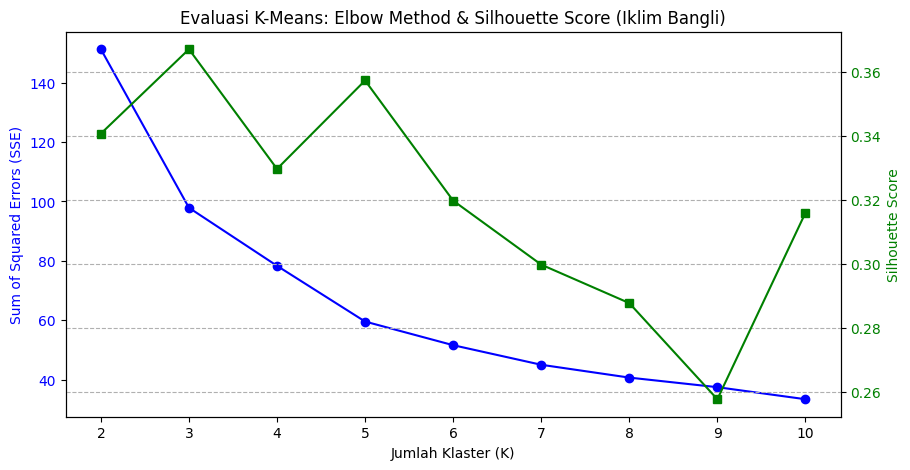

In [ ]:
# --- TAHAP 3: EVALUASI K-MEANS (MENCARI NILAI K OPTIMAL) ---
sse = []
silhouette_scores = []
K_range = range(2, 11) # Menguji pembentukan klaster dari K=2 hingga K=10

for k in K_range:
    # Menginisialisasi dan melatih algoritma K-Means pada iterasi K saat ini
    kmeans_uji = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans_uji.fit(X_iklim_scaled)

    # Mengekstrak metrik evaluasi dan menyimpannya ke dalam list
    sse.append(kmeans_uji.inertia_) # Mengukur kerapatan jarak (untuk Elbow Method)
    silhouette_scores.append(silhouette_score(X_iklim_scaled, kmeans_uji.labels_)) # Mengukur akurasi pemisahan

# Membuat kanvas grafik ganda
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot garis pertama: SSE (Sumbu Y kiri)
ax1.plot(K_range, sse, marker='o', color='b', label='SSE (Elbow)')
ax1.set_xlabel('Jumlah Klaster (K)')
ax1.set_ylabel('Sum of Squared Errors (SSE)', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Plot garis kedua: Silhouette Score (Sumbu Y kanan)
ax2 = ax1.twinx() # .twinx() krusial untuk menggabungkan dua grafik dengan skala angka yang berbeda
ax2.plot(K_range, silhouette_scores, marker='s', color='g', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='g')
ax2.tick_params(axis='y', labelcolor='g')

plt.title('Evaluasi K-Means: Elbow Method & Silhouette Score (Iklim Bangli)')
plt.grid(True, linestyle='--')
plt.show()

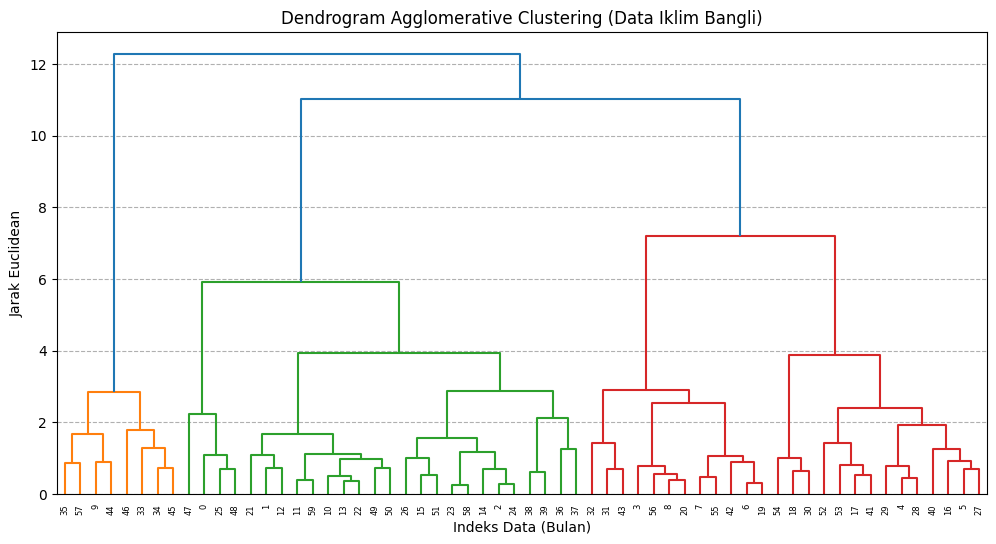


=== PROFIL RATA-RATA KLASTER (BAHAN ANALISIS LAPORAN) ===
PARAMETER       PRECTOTCORR    T2M   RH2M  ALLSKY_SFC_SW_DWN
Klaster_KMeans                                              
0                      9.30  27.32  81.75              18.74
1                      1.63  26.37  80.07              19.19
2                      2.34  27.87  75.45              23.21

Berhasil! Dataset telah disimpan dengan nama: Dataset1_Iklim_Bangli_Clustered.csv


In [ ]:
# --- TAHAP 4: EKSEKUSI FINAL CLUSTERING (K-MEANS & AGGLOMERATIVE) ---

# Tentukan nilai K optimal berdasarkan grafik Elbow & Silhouette sebelumnya
# (Asumsi kita menggunakan 3 klaster. Silakan ganti jika grafikmu menunjukkan angka lain).
optimal_k = 3

# 1. Menjalankan Model K-Means Final
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
# Menyimpan hasil klaster K-Means sebagai kolom baru di dataframe kita
df_pivoted['Klaster_KMeans'] = kmeans_final.fit_predict(X_iklim_scaled)

# 2. Menjalankan Model Agglomerative Clustering
agglo_model = AgglomerativeClustering(n_clusters=optimal_k, metric='euclidean', linkage='ward')
# Menyimpan hasil klaster Agglomerative sebagai kolom baru
df_pivoted['Klaster_Agglo'] = agglo_model.fit_predict(X_iklim_scaled)

# 3. Visualisasi Wajib: Dendrogram untuk Agglomerative
plt.figure(figsize=(12, 6))
# sch.linkage akan menghitung matriks jarak hirarki secara berjenjang
dendrogram = sch.dendrogram(sch.linkage(X_iklim_scaled, method='ward'))
plt.title('Dendrogram Agglomerative Clustering (Data Iklim Bangli)')
plt.xlabel('Indeks Data (Bulan)')
plt.ylabel('Jarak Euclidean')
plt.grid(True, axis='y', linestyle='--')
plt.show()

# TAHAP 5: EKSTRAKSI PROFIL KLASTER UNTUK BAHAN LAPORAN PDF
print("\n=== PROFIL RATA-RATA KLASTER (BAHAN ANALISIS LAPORAN) ===")
# Mengelompokkan data berdasarkan klaster dan menghitung rata-rata setiap parameternya
profil_klaster = df_pivoted.groupby('Klaster_KMeans')[fitur_iklim].mean().round(2)
print(profil_klaster)


# TAHAP 6: EKSPOR DATA UNTUK PENGUMPULAN TUGAS
nama_file_output = 'Dataset1_Iklim_Bangli_Clustered.csv'
df_pivoted.to_csv(nama_file_output, index=False)
print(f"\nBerhasil! Dataset telah disimpan dengan nama: {nama_file_output}")